# Lab 4: Hugging Face Transformers - Traduccion Automatica y Modelos Multimodales (VLM)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jggomez/workshop-open-source-models/blob/main/session-01-hf-kerashub-litert/04-huggingface-translation/notebook.ipynb)

## Objetivo
1. Dominar el uso de **`pipeline()`** de Hugging Face para tareas de Sequence-to-Sequence (traduccion automatica).
2. Implementar modelos multimodales Vision-Language (VLM) utilizando **`AutoProcessor`** y **`AutoModelForMultimodalLM`** para razonamiento conjunto de imagen y texto.

### Paso 1: Instalacion de Dependencias

In [1]:
!pip install -q transformers torch sentencepiece sacremoses accelerate pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 51.3 MB/s eta 0:00:00


## PARTE 1: Traduccion Automatica con `from transformers import pipeline`
La funcion `pipeline()` permite abstraer la tokenizacion, forward-pass y decodificacion de salida en una sola llamada.

In [7]:
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import time

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
model_id = "Helsinki-NLP/opus-mt-es-en"

print(f"Cargando tokenizer y modelo: {model_id} (Hardware: {device.upper()})...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id).to(device)

# Perform translation manually, bypassing the pipeline's task registry issue
def translate_text(text_to_translate, max_len=128):
    inputs = tokenizer(text_to_translate, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        translated_tokens = model.generate(**inputs, max_length=max_len)
    return tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)

text = "El despliegue de modelos de codigo abierto en produccion requiere optimizacion de latencia y gestion eficiente de recursos."

start_t = time.time()
res = translate_text(text, max_len=128)
elapsed = (time.time() - start_t) * 1000

print(f"\nTexto Original : {text}")
print(f"Traduccion     : {res[0]}")
print(f"Tiempo de inferencia: {elapsed:.2f} ms")

Cargando tokenizer y modelo: Helsinki-NLP/opus-mt-es-en (Hardware: CUDA)...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]


Texto Original : El despliegue de modelos de codigo abierto en produccion requiere optimizacion de latencia y gestion eficiente de recursos.
Traduccion     : The deployment of open code models in production requires optimization of latency and efficient management of resources.
Tiempo de inferencia: 1057.43 ms


### Procesamiento por Lotes (Batch Translation)

In [9]:
sentences = [
    "Los modelos de lenguaje requieren tecnicas de cuantizacion para ejecutarse en el borde.",
    "Hugging Face proporciona un repositorio centralizado de pesos y conjuntos de datos.",
    "KerasHub desacopla el preprocesamiento del cabezal de clasificacion."
]

start_t = time.time()
# Use translate_text function and remove num_beams as it's not supported by its current definition
batch_results = translate_text(sentences, max_len=128)
elapsed = (time.time() - start_t) * 1000

for original, translated_text in zip(sentences, batch_results):
    print(f"ES: {original}")
    # The translate_text function returns a list of strings directly
    print(f"EN: {translated_text}\n")
print(f"Tiempo total de procesamiento por lotes: {elapsed:.2f} ms")

ES: Los modelos de lenguaje requieren tecnicas de cuantizacion para ejecutarse en el borde.
EN: Language models require quantity techniques to run on the edge.

ES: Hugging Face proporciona un repositorio centralizado de pesos y conjuntos de datos.
EN: Hugging Face provides a centralized repository of weights and data sets.

ES: KerasHub desacopla el preprocesamiento del cabezal de clasificacion.
EN: KerasHub decouples the preprocessing of the sorting head.

Tiempo total de procesamiento por lotes: 180.14 ms


## PARTE 2: Modelos Multimodales con `AutoProcessor` y `AutoModelForMultimodalLM`
Los Vision-Language Models (VLM) integran un codificador de imagen con un transformador autorregresivo de lenguaje para resolver preguntas visuales (Visual Question Answering) y describir escenas.

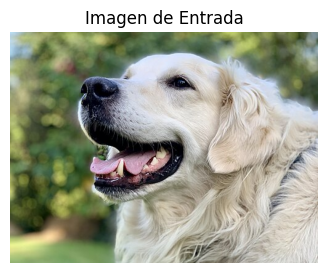

In [10]:
import urllib.request, ssl, os
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForMultimodalLM

os.makedirs("sample_images", exist_ok=True)
dog_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b3/Golden_Retriever_2019.jpg/500px-Golden_Retriever_2019.jpg"
dog_path = "sample_images/dog.jpg"

if not os.path.exists(dog_path):
    ctx = ssl._create_unverified_context()
    req = urllib.request.Request(dog_url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, context=ctx) as r, open(dog_path, "wb") as f:
        f.write(r.read())

sample_image = Image.open(dog_path).convert("RGB")
plt.figure(figsize=(4, 3))
plt.imshow(sample_image)
plt.axis("off")
plt.title("Imagen de Entrada")
plt.show()

### Carga de `AutoProcessor` y `AutoModelForMultimodalLM`

In [11]:
vlm_model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"
print(f"Cargando procesador y modelo multimodal: {vlm_model_id}...")

processor = AutoProcessor.from_pretrained(vlm_model_id)
vlm_model = AutoModelForMultimodalLM.from_pretrained(
    vlm_model_id,
    torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
    low_cpu_mem_usage=True
).to(device)
vlm_model.eval()
print("Modelo multimodal listo para inferencia.")

Cargando procesador y modelo multimodal: HuggingFaceTB/SmolVLM-256M-Instruct...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Modelo multimodal listo para inferencia.


### Ejecucion de Razonamiento Multimodal (VQA)

In [12]:
user_prompt = "Describe this image in detail, identify the dog breed, and describe its surroundings."

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": user_prompt}
        ]
    }
]

prompt_text = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt_text, images=sample_image, return_tensors="pt").to(device)

start_vlm = time.time()
with torch.no_grad():
    generated_ids = vlm_model.generate(**inputs, max_new_tokens=64, do_sample=False)

input_len = inputs.input_ids.shape[1]
new_tokens = generated_ids[0][input_len:]
answer = processor.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
elapsed_vlm = time.time() - start_vlm

print(f"Pregunta : {user_prompt}")
print(f"Respuesta VLM : {answer}")
print(f"Tiempo de inferencia multimodal: {elapsed_vlm:.2f} s ({len(new_tokens)/elapsed_vlm:.1f} tokens/s)")

Pregunta : Describe this image in detail, identify the dog breed, and describe its surroundings.
Respuesta VLM : The image features a close-up view of a dog's mouth and tongue. The dog's mouth is open, and its tongue is visible, showing a dark hue. The tongue is positioned in the center of the image, with the dog's mouth slightly tilted upwards. The dog's fur is light-colored, possibly
Tiempo de inferencia multimodal: 3.27 s (19.6 tokens/s)


In [15]:
import gc

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Memoria VRAM/RAM y recursos multimodales liberados exitosamente.')

Memoria VRAM/RAM y recursos multimodales liberados exitosamente.
